# CUDA - 粒子模擬

---

In [9]:
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

# [Part 1.] CPU、GPU -> 輸出效率比較圖

**lab.cu** -> **time.png**

In [10]:
%%writefile lab.cu

#include <iostream>
#include <vector>
#include <iomanip>
#include <cmath>
#include <chrono>
#include <cuda_runtime.h>

using namespace std;

struct Particle {
    float x, y;
};

__host__ __device__
float rand(int i, int step, int seed) {
    int n = i * 1973 + step * 9277 + seed * 26699;
    n = (n << 13) ^ n;
    return 1.0f - ((n * (n * n * 15731 + 789221) + 1376312589) & 0x7fffffff) / 1073741824.0f;
}

void cpu(vector<Particle>& p, int N, int steps, float dt, float wind_x, float wind_y, float diff, float settle) {
    for (int step = 0; step < steps; step++) {
        for (int i = 0; i < N; i++) {
            float rx = rand(i, step, 1) * diff;
            float ry = rand(i, step, 2) * diff;

            p[i].x += wind_x * dt + rx;
            p[i].y += wind_y * dt + ry - settle * dt;

            if (p[i].x < 0) p[i].x = 0;
            if (p[i].x > 100) p[i].x = 100;
            if (p[i].y < 0) p[i].y = 0;
            if (p[i].y > 100) p[i].y = 100;
        }
    }
}


__global__ void gpu(Particle* p, int N, int step, float dt, float wind_x, float wind_y, float diff, float settle) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        float rx = rand(i, step, 1) * diff;
        float ry = rand(i, step, 2) * diff;

        float x = p[i].x + wind_x * dt + rx;
        float y = p[i].y + wind_y * dt + ry - settle * dt;

        if (x < 0) x = 0;
        if (x > 100) x = 100;
        if (y < 0) y = 0;
        if (y > 100) y = 100;

        p[i].x = x;
        p[i].y = y;
    }
}

int main() {
    const int N = 300000; //修改粒子數
    const int STEPS = 1000;
    const float dt = 0.1f;

    const float wind_x = 0.75f;
    const float wind_y = 0.25f;
    const float diff = 0.12f;
    const float settle = 0.02f;

    vector<Particle> init_particles(N);
    for (int i = 0; i < N; i++) {
        init_particles[i] = {20.0f, 20.0f};
    }

    // CPU
    vector<Particle> cpu_particles = init_particles;

    auto cpu_start = chrono::high_resolution_clock::now();
    cpu(cpu_particles, N, STEPS, dt, wind_x, wind_y, diff, settle);
    auto cpu_end = chrono::high_resolution_clock::now();
    double cpu_time_ms = chrono::duration<double, milli>(cpu_end - cpu_start).count();

    // GPU
    vector<Particle> gpu_particles = init_particles;

    Particle* d_particles = nullptr;
    cudaMalloc(&d_particles, N * sizeof(Particle));
    cudaMemcpy(d_particles, gpu_particles.data(), N * sizeof(Particle), cudaMemcpyHostToDevice);

    int blockSize = 256;
    int gridSize = (N + blockSize - 1) / blockSize;

    cudaEvent_t gstart, gstop;
    cudaEventCreate(&gstart);
    cudaEventCreate(&gstop);

    cudaEventRecord(gstart);
    for (int t = 0; t < STEPS; t++) {
        gpu<<<gridSize, blockSize>>>(
            d_particles, N, t, dt, wind_x, wind_y, diff, settle
        );


    }
    cudaEventRecord(gstop);
    cudaEventSynchronize(gstop);

    float gpu_time_ms = 0.0f;
    cudaEventElapsedTime(&gpu_time_ms, gstart, gstop);

    cudaMemcpy(gpu_particles.data(), d_particles, N * sizeof(Particle), cudaMemcpyDeviceToHost);

    cout << fixed << setprecision(4);
    cout << "N         : " << N << endl;
    cout << "CPU Time  : " << cpu_time_ms << " ms" << endl;
    cout << "GPU Time  : " << gpu_time_ms << " ms" << endl;
    cout << "Speedup   : " << (cpu_time_ms / gpu_time_ms) << "x" << endl;

    cudaFree(d_particles);
    cudaEventDestroy(gstart);
    cudaEventDestroy(gstop);
    return 0;
}

Writing lab.cu


In [11]:
!nvcc -arch=sm_75 lab.cu -o lab
!./lab

N         : 300000
CPU Time  : 8593.4958 ms
GPU Time  : 9.7195 ms
Speedup   : 884.1540x


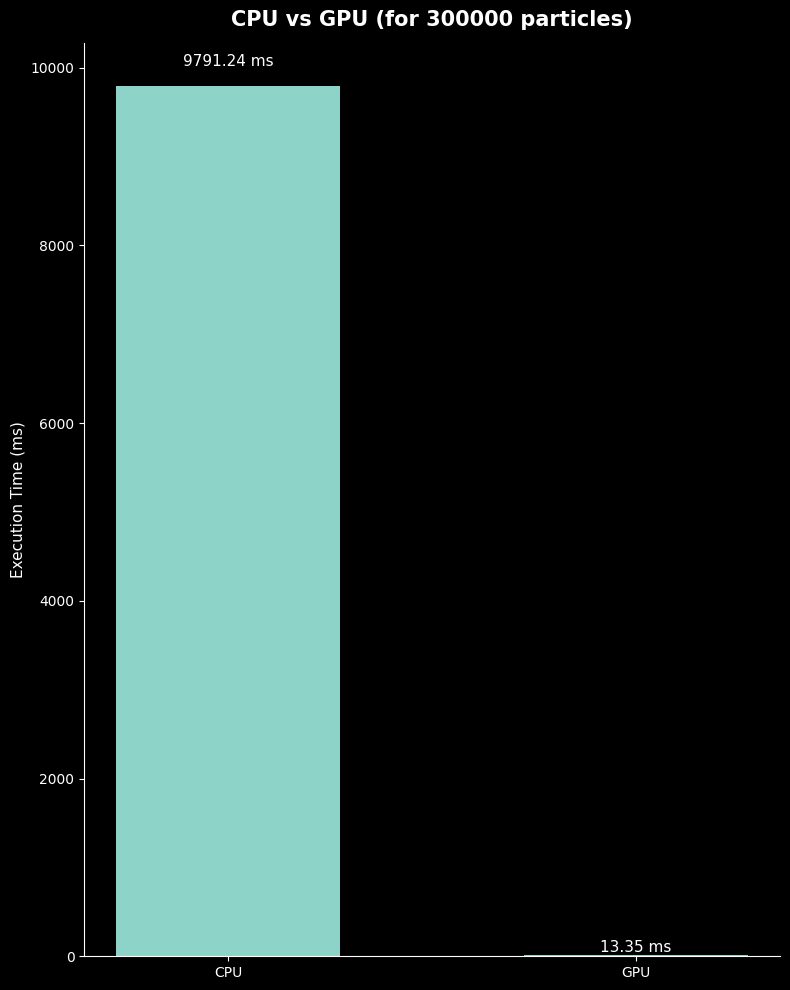

In [12]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

cpu_time = 9791.2386
gpu_time = 13.3467

data = {
    "CPU": cpu_time,
    "GPU": gpu_time
}

methods = list(data.keys())
times = list(data.values())

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 10)) #改圖片長寬

bars = ax.bar(methods, times, width=0.55)

# 數值標註
for bar, val in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.02,
        f"{val:.2f} ms",
        ha="center",
        va="bottom",
        fontsize=11,
        color="white"
    )

ax.set_ylabel("Execution Time (ms)", fontsize=11)
ax.set_title("CPU vs GPU (for 300000 particles)", fontsize=15, fontweight="bold", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("time.png", dpi=300, bbox_inches="tight")
plt.show()

# [Part 2.] GPU -> 輸出視覺化GIF

視覺顯示大氣粒子在城市中的擴散情形

**lab_draw.cu** -> **output/frame_0000-0200.csv** -> **particle_animation.gif**

In [13]:
%%writefile lab_draw.cu

#include <iostream>
#include <vector>
#include <fstream>
#include <sstream>
#include <iomanip>
#include <cmath>
#include <cuda_runtime.h>

using namespace std;

struct Particle {
    float x, y;
};

__host__ __device__
float rand(int i, int step, int seed) {
    int n = i * 1973 + step * 9277 + seed * 26699;
    n = (n << 13) ^ n;
    return 1.0f - ((n * (n * n * 15731 + 789221) + 1376312589) & 0x7fffffff) / 1073741824.0f;
}

__global__ void gpu(Particle* p, int N, int step, float dt, float wind_x, float wind_y, float diff, float settle) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        float rx = rand(i, step, 1) * diff;
        float ry = rand(i, step, 2) * diff;

        p[i].x += wind_x * dt + rx;
        p[i].y += wind_y * dt + ry - settle * dt;

        if (p[i].x < 0) p[i].x = 0;
        if (p[i].x > 100) p[i].x = 100;
        if (p[i].y < 0) p[i].y = 0;
        if (p[i].y > 100) p[i].y = 100;
    }
}

void save_particles_to_csv(const vector<Particle>& particles, int frame_id) {
    ostringstream filename; //單純拼字串
    filename << "output/frame_" << setw(4) << setfill('0') << frame_id << ".csv";

    ofstream file(filename.str()); //把剛剛組好的檔名字串，拿去開檔案
    file << "x,y\n"; //寫進檔案
    for (const auto& p : particles) {
        file << p.x << "," << p.y << "\n";
    }
    file.close();
}

int main() {
    const int N = 10000;       //粒子數
    const int STEPS = 1000;      //總步數
    const int SAVE_EVERY = 5;   //每幾步輸出一次
    const float dt = 0.1f;

    // 風場：往右上吹
    const float wind_x = 0.75f;
    const float wind_y = 0.25f;

    // 擴散與沉降
    const float diff = 0.6f;
    const float settle = 0.05f;

    vector<Particle> h_particles(N);

    // 初始污染源：城市左下角偏中
    for (int i = 0; i < N; i++) {
        h_particles[i] = {20.0f, 20.0f};
    }

    Particle* d_particles;
    cudaMalloc(&d_particles, N * sizeof(Particle));
    cudaMemcpy(d_particles, h_particles.data(), N * sizeof(Particle), cudaMemcpyHostToDevice);

    int blockSize = 256;
    int gridSize = (N + blockSize - 1) / blockSize;

    int frame_id = 0;

    // 先存初始狀態
    save_particles_to_csv(h_particles, frame_id++);

    for (int t = 0; t < STEPS; t++) {
        gpu<<<gridSize, blockSize>>>(
            d_particles, N, t, dt, wind_x, wind_y, diff, settle
        );
        cudaDeviceSynchronize();

        if ((t + 1) % SAVE_EVERY == 0) {
            cudaMemcpy(h_particles.data(), d_particles, N * sizeof(Particle), cudaMemcpyDeviceToHost);
            save_particles_to_csv(h_particles, frame_id++);
            cout << "Saved frame " << frame_id - 1 << endl;
        }
    }

    cudaFree(d_particles);
    cout << "Simulation finished." << endl;
    return 0;
}

Writing lab_draw.cu


In [14]:
!mkdir -p output
!nvcc -arch=sm_75 lab_draw.cu -o lab_draw
!./lab_draw

Saved frame 1
Saved frame 2
Saved frame 3
Saved frame 4
Saved frame 5
Saved frame 6
Saved frame 7
Saved frame 8
Saved frame 9
Saved frame 10
Saved frame 11
Saved frame 12
Saved frame 13
Saved frame 14
Saved frame 15
Saved frame 16
Saved frame 17
Saved frame 18
Saved frame 19
Saved frame 20
Saved frame 21
Saved frame 22
Saved frame 23
Saved frame 24
Saved frame 25
Saved frame 26
Saved frame 27
Saved frame 28
Saved frame 29
Saved frame 30
Saved frame 31
Saved frame 32
Saved frame 33
Saved frame 34
Saved frame 35
Saved frame 36
Saved frame 37
Saved frame 38
Saved frame 39
Saved frame 40
Saved frame 41
Saved frame 42
Saved frame 43
Saved frame 44
Saved frame 45
Saved frame 46
Saved frame 47
Saved frame 48
Saved frame 49
Saved frame 50
Saved frame 51
Saved frame 52
Saved frame 53
Saved frame 54
Saved frame 55
Saved frame 56
Saved frame 57
Saved frame 58
Saved frame 59
Saved frame 60
Saved frame 61
Saved frame 62
Saved frame 63
Saved frame 64
Saved frame 65
Saved frame 66
Saved frame 67
Save

### Python 做動畫的步驟：
1. 準備資料
2. 建立畫布
3. 畫固定不動的東西
4. 設定動畫：每一幀要更新什麼 (init, update
5. 存成 GIF/影片

Saved particle_animation.gif


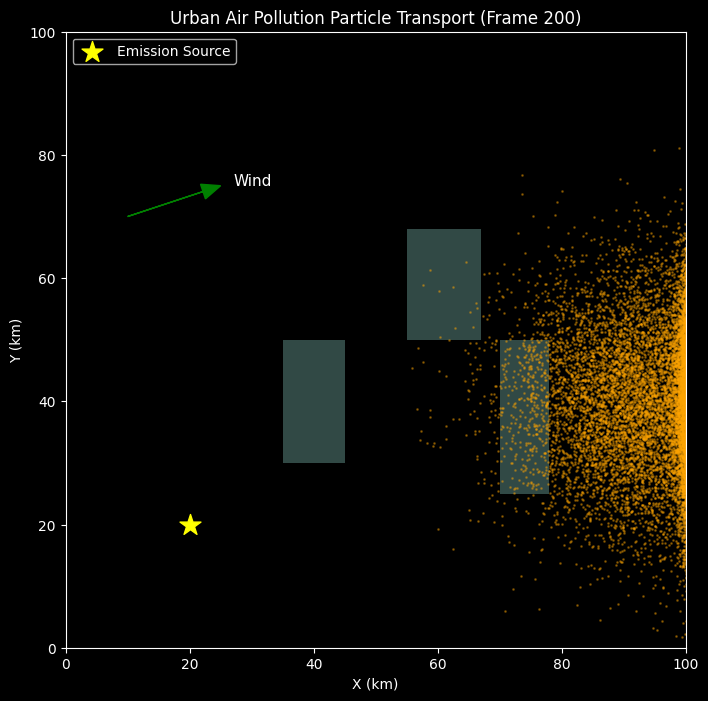

In [15]:
import os
import glob
import numpy as np # numpy 高效能多微陣列運算
import pandas as pd # pandas 讀取、操作表格資料 (python的excel)
import matplotlib.pyplot as plt # matplotlib 畫圖
import matplotlib.animation as animation
from matplotlib.patches import Rectangle

# 1. 找出 output 資料夾中所有 frame_xxx.csv 檔案，依檔名排序
files = sorted(glob.glob("output/frame_*.csv"))

# 2. 建立畫布與座標軸，8x8
fig, ax = plt.subplots(figsize=(8, 8)) # fig畫布,ax座標區

ax.set_xlim(0, 100) # 設定x軸從0-100
ax.set_ylim(0, 100) # 設定y軸從0-100
ax.set_xlabel("X (km)") # x坐標軸名稱
ax.set_ylabel("Y (km)") # y坐標軸名稱
ax.set_title("Urban Air Pollution Particle Transport") # 標題名稱

# 3. 畫圖：建築物
buildings = [
    Rectangle((35, 30), 10, 20, alpha=0.35), # 建築物1：左下角(35,30)，寬10，高20, 透明度35%
    Rectangle((55, 50), 12, 18, alpha=0.35), # 建築物2
    Rectangle((70, 25), 8, 25, alpha=0.35)  # 建築物3
]
for b in buildings:
    ax.add_patch(b) # 因為固定就直接畫到圖上


# 3. 畫圖：污染源
ax.scatter([20], [20], marker="*", s=250, label="Emission Source", c="yellow")

# 3. 畫圖：風場箭頭
ax.arrow(10, 70, 15, 5, head_width=2.5, head_length=3, length_includes_head=True, color="green")
ax.text(27, 75, "Wind", fontsize=11)

# 3. 畫圖：粒子 (剛開始給空資料)
scatter = ax.scatter([], [], s=1, alpha=0.35, c="orange")

ax.legend(loc="upper left") # 顯示圖例label

# 4. 做動畫

# 初始化
def init():
    scatter.set_offsets(np.empty((0, 2))) # 在動畫開始前，先把粒子位置清空
    return (scatter,)

# 更新
def update(frame_idx):
    df = pd.read_csv(files[frame_idx]) # 讀取對應幀的 csv 檔
    offsets = df[["x", "y"]].to_numpy() # 取出 x, y 欄位，轉成 numpy array

    scatter.set_offsets(offsets) # 更新所有粒子的位置
    ax.set_title(f"Urban Air Pollution Particle Transport (Frame {frame_idx})") # 更新標題
    return (scatter,)

# 建立動畫
ani = animation.FuncAnimation(fig, update, frames=len(files), init_func=init, interval=120, blit=True)


# 5. 儲存成 GIF
ani.save("particle_animation.gif", writer="pillow", fps=8) # 每秒 8 幀
print("Saved particle_animation.gif")

# 因為要跑過200多個檔案，這裡要跑30多秒是正常的

# <小工具> 清空目前檔案中的所有檔案（txt, png...）

最好每次重新跑流程前先清空，以保持乾淨，避免舊檔案的干擾喔！

In [8]:
!rm -rf /content/*